# Investigating MNIST RLCT values using NGD and SGD

This notebook is the first in the MARS research project led by Moosa Saghir, Zach Liu, and Ragha Rao, investigating the central claim of SLT - namely that SGD converges towards sets of model parameters that yield a lower model complexity. To this end, we will use both the "real log canonical threshold" (RLCT) and the Hessian to measure model complexity.

If SLT predictions are correct, we expect that SGD will yield models with lower Hessian eigenvalues and a lower RLCT value, compared to NGD (natural gradient descent, which is a modified variant of gradient descent that premultiplies the loss gradient with the inverse of the Fisher information matrix).

## Methodology

We use a very simple network architecture:
*   128 neuron hidden layer
*   ReLU activation
*   Dropout with 0.5 probability
*   10 neuron output layer
*   Return log softmax probabilities

In future notebooks, we will also train small transformer models and CNNs. But for now we'll stick to a simple example to get started.

For different model architectures, we train the model using various gradient descent algorithms, including: SGD, Momentum, Adam, and NGD. We then calculate the Hessian and the RLCT at the minima converged to. This will allow comparison of the model complexities achieved by different gradient descent algorithms.

## **TO BE COMPLETED=====================================**
* Need to vary model architecture and see how this affects RLCT
* Need to calculate Hessian for different optimizers / architectures



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/MARS

In [8]:
!git init
!git add .
!git commit -m "initial model setup"
!git remote add origin https://github.com/cxtraa/ngd_with_slt.git
!git config --global user.email "your_email@example.com"
!git config --global user.name "Your Name"
!git push -u origin main

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/MARS/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@7cf0cfa44fb9.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/cxtraa/ngd_w

In [ ]:
# Install required dependencies
!pip install einops
!pip install devinterp
!pip install wandb
!pip install tqdm

In [2]:
# Import required libraries

import os
import sys
import numpy as np
import einops

import torch as t
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, random_split

from tqdm import tqdm
import json
import wandb

from devinterp.slt import estimate_learning_coeff
from devinterp.optim.sgld import SGLD

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

device = "cuda" if t.cuda.is_available() else "cpu"

/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/local/lib/python3.10/dist-packages/torchvision/image.so: undefined symbol: _ZN3c104cuda9SetDeviceEi'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [ ]:
# Define MNIST model architecture

class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

model = NeuralNet().to(device)
print(model)

In [4]:
# Define model hyperparameters, loss function, and optimizers

hyperparams = {
    "lr": 1e-5,
    "batch_size" : 128,
    "num_epochs" : 20,
    "momentum" : 0.8,
}

criterion = nn.CrossEntropyLoss()
sgd = t.optim.SGD(
    model.parameters(),
    lr=hyperparams["lr"],
    )
adam = t.optim.Adam(
    model.parameters(),
    lr=hyperparams["lr"],
    )
rmsprop = t.optim.RMSprop(
    model.parameters(),
    lr=hyperparams["lr"],
    momentum=hyperparams["momentum"],
)
optimizers = [sgd, adam, rmsprop]

In [5]:
# Load MNIST data

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = t.utils.data.DataLoader(train_set, batch_size=hyperparams["batch_size"], shuffle=True)
test_loader = t.utils.data.DataLoader(test_set, batch_size=hyperparams["batch_size"], shuffle=False)

100%|██████████| 9912422/9912422 [00:00<00:00, 104742390.39it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 101709230.75it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 122381331.01it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 7450343.67it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [6]:
# Define training and evaluation functions

def train_one_epoch(model, train_loader, optimizer, criterion):
    model.train()
    train_loss = 0
    for image, label in tqdm(train_loader):
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    return train_loss / len(train_loader)

def evaluate(model, test_loader, criterion):
    model.eval()
    test_loss = 0
    with t.no_grad():
        for image, label in test_loader:
            image, label = image.to(device), label.to(device)
            output = model(image)
            loss = criterion(output, label)
            test_loss += loss.item()
    return test_loss / len(test_loader)


In [ ]:
# Train the model
train_losses = []
test_losses = []
models = {}
for optimizer in optimizers:
    name = f"{optimizer.__class__.__name__}"
    print(f"\n======================== Training with {name} ==========================")
    for epoch in range(hyperparams["num_epochs"]):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        test_loss = evaluate(model, test_loader, criterion)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        if name in models:
            models[name].append(model)
        else:
            models[name] = [model]
        print(f"Epoch {epoch+1}/{hyperparams['num_epochs']}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")

In [ ]:
# Initialise wandb

wandb.login()
wandb.init(project="MNIST RLCT measurements", entity="moosasaghir10")

In [ ]:
print(models)

In [ ]:
# Perform chain analysis of RLCT value for models saved during training

rlct_estimates = {}
for optimizer in models:
    print(f"======================== RLCT estimates for {optimizer} ==========================")
    for m in models[optimizer]:
        rlct_estimate = estimate_learning_coeff(
            m,
            train_loader,
            criterion=criterion,
            optimizer_kwargs=dict(
                lr=hyperparams["lr"],
                noise_level=1.0,
                elasticity=100.0,
                num_samples=len(train_set),
                temperature="adaptive",
            ),
            sampling_method=SGLD,
            num_chains=1,
            num_draws=400,
            num_burnin_steps=0,
            num_steps_bw_draws=1,
            device=device,
        )
        if optimizer in rlct_estimates:
            rlct_estimates[optimizer].append(rlct_estimate)
        else:
            rlct_estimates[optimizer] = [rlct_estimate]
        print(f"RLCT estimate: {rlct_estimate}")

In [ ]:
# Save data as a bar plot to wandb

optimizer_rlct_vals = [[key, value[-1]] for key, value in rlct_estimates.items()]
table = wandb.Table(data=optimizer_rlct_vals, columns=["optimizer", "rlct"])
wandb.log({"Optimizer RLCT values" : wandb.plot.bar(table, "optimizer", "rlct", title="Optimizer RLCT values")})
wandb.finish()

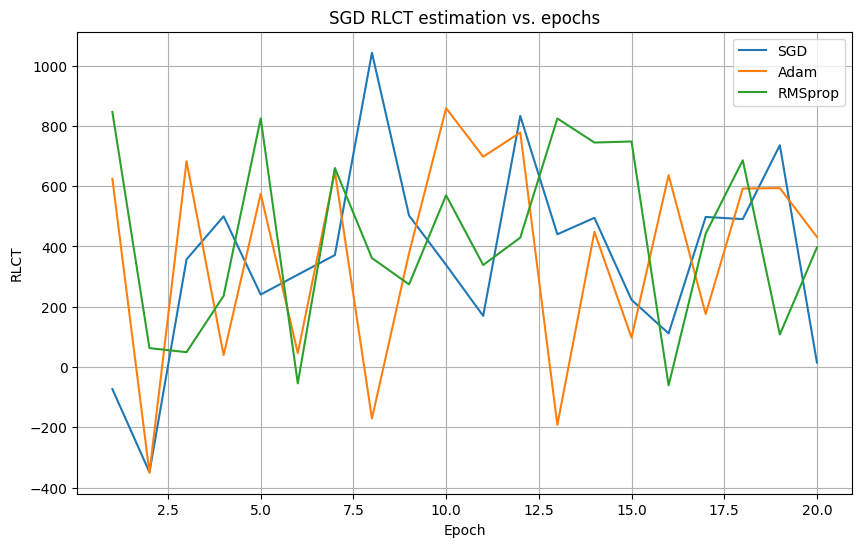

In [ ]:
# Quick graphs to visualise how RLCT evolved over time
plt.figure(figsize=(10, 6))
optims = ["SGD", "Adam", "RMSprop"]
for optim in optims:
    plt.plot(np.arange(1, hyperparams["num_epochs"]+1), rlct_estimates[optim], label=optim)
plt.grid()
plt.title("SGD RLCT estimation vs. epochs")
plt.xlabel("Epoch")
plt.ylabel("RLCT")
plt.legend()